In [65]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns # making statistical graphics
from scipy import stats


from sklearn.svm import SVC 
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, StackingClassifier
#import xgboost as xgb
#from catboost import CatBoostClassifier
#from lightgbm import LGBMClassifier


from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, MinMaxScaler

#from imblearn.over_sampling import SMOTE




# Description Data

In [66]:
train_df = pd.read_csv("train.csv")
test_df  = pd.read_csv("test.csv")

print("training dataset shape is: ",train_df.shape)
print("testing dataset shape is " ,test_df.shape)

train_df.head()

training dataset shape is:  (8693, 14)
testing dataset shape is  (4277, 13)


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [67]:
print(f"Duplicates in train dataset is  {train_df.duplicated().sum()}, donc comme pourcentage ({100*train_df.duplicated().sum()/len(train_df)})%")

print("data types of features of training data")
print(train_df.dtypes)
print("\n"+"-"*100)
print("\nData type of testing data is")
print(test_df.dtypes)

Duplicates in train dataset is  0, donc comme pourcentage (0.0)%
data types of features of training data
PassengerId      object
HomePlanet       object
CryoSleep        object
Cabin            object
Destination      object
Age             float64
VIP              object
RoomService     float64
FoodCourt       float64
ShoppingMall    float64
Spa             float64
VRDeck          float64
Name             object
Transported        bool
dtype: object

----------------------------------------------------------------------------------------------------

Data type of testing data is
PassengerId      object
HomePlanet       object
CryoSleep        object
Cabin            object
Destination      object
Age             float64
VIP              object
RoomService     float64
FoodCourt       float64
ShoppingMall    float64
Spa             float64
VRDeck          float64
Name             object
dtype: object


Check percentage missing values train data

In [68]:
df1 = (train_df.isnull().sum()[train_df.isnull().sum()>0]).to_frame().rename(columns={0:"Number of Missing values"})
df1["% of Missing values"] = round((100*train_df.isnull().sum()[train_df.isnull().sum()>0]/len(train_df)),2)
df1

,Number of Missing values,% of Missing values
HomePlanet,201,2.31
CryoSleep,217,2.50
Cabin,199,2.29
Destination,182,2.09
Age,179,2.06
VIP,203,2.34
RoomService,181,2.08
FoodCourt,183,2.11
ShoppingMall,208,2.39
Spa,183,2.11


check percentage missing values test data

In [69]:
df2 = (test_df.isnull().sum()[test_df.isnull().sum()>0]).to_frame().rename(columns={0:"Number of Missing values"})
df2["% of Missing Values"] = round((100*test_df.isnull().sum()[test_df.isnull().sum()>0]/len(test_df)),2).values
df2

,Number of Missing values,% of Missing Values
HomePlanet,87,2.03
CryoSleep,93,2.17
Cabin,100,2.34
Destination,92,2.15
Age,91,2.13
VIP,93,2.17
RoomService,82,1.92
FoodCourt,106,2.48
ShoppingMall,98,2.29
Spa,101,2.36


Cardinal of features of type object

In [70]:
print("cardinality of categorical features in training datasets is:")
print(train_df.select_dtypes(include="object").nunique())
print("\n","-"*70)
print("\nCardinality of categorical features in testing datsets is:")
print(test_df.select_dtypes(include="object").nunique())

cardinality of categorical features in training datasets is:
PassengerId    8693
HomePlanet        3
CryoSleep         2
Cabin          6560
Destination       3
VIP               2
Name           8473
dtype: int64

 ----------------------------------------------------------------------

Cardinality of categorical features in testing datsets is:
PassengerId    4277
HomePlanet        3
CryoSleep         2
Cabin          3265
Destination       3
VIP               2
Name           4176
dtype: int64


PassagerId Cabin and Name high cardinality 

we create new feature from this features

# Exploratory data analysis

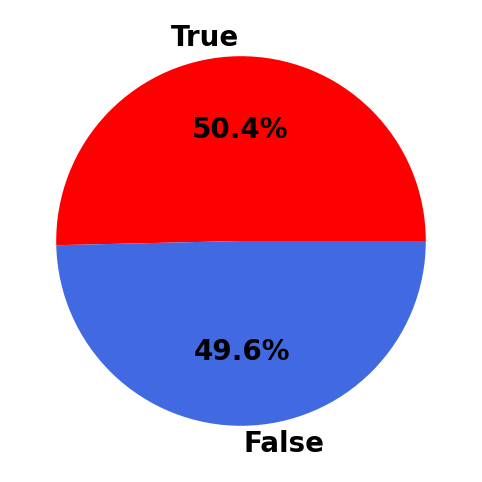

In [71]:
plt.figure(figsize=(10, 6))

# Définition explicite des couleurs inversées
colors = ["red", "royalblue"]  # Rouge pour False, Bleu pour True, par exemple

plt.pie(
    train_df["Transported"].value_counts(),
    labels=train_df['Transported'].value_counts().keys(),
    autopct="%1.1f%%",
    textprops={"fontsize": 20, "fontweight": "black"},
    colors=colors  # Utilisation des couleurs définies
)

plt.show()

We can observe that our Transported Feature is highly balanced.

dont need to use techniques like under_sampling or over_sampling

Age feature visualizing 

c:\Users\colin\anaconda3\envs\Alaska\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


Text(0.5, 1.0, 'Age feature distribution')

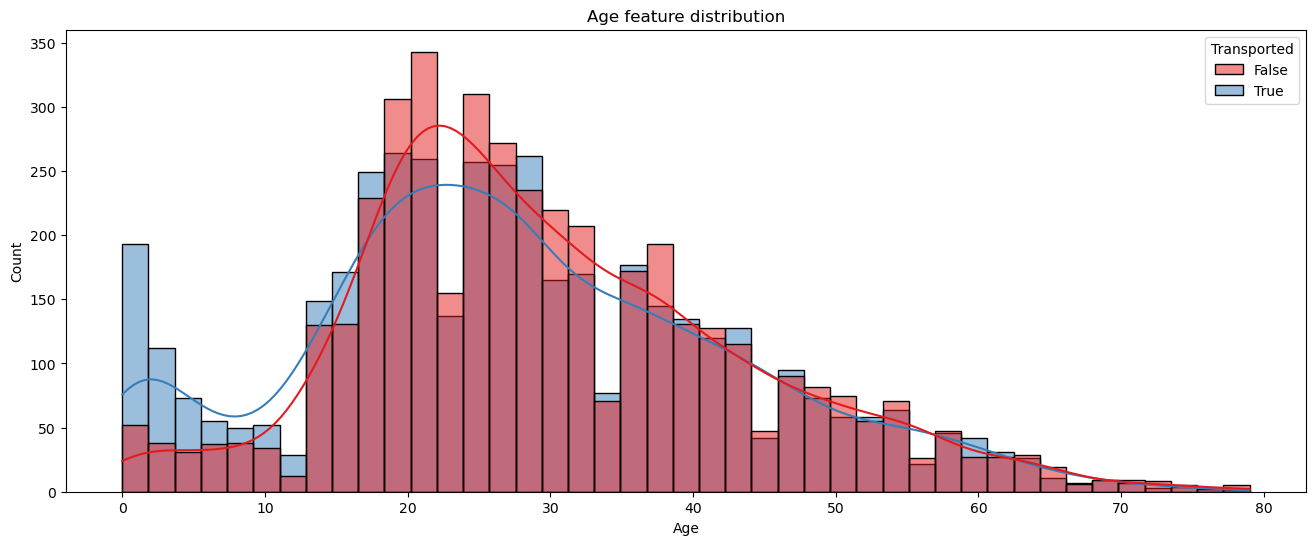

In [72]:
plt.figure(figsize=(16,6))
sns.histplot(x=train_df["Age"], hue="Transported",data=train_df, kde=True,  palette="Set1")
plt.title("Age feature distribution")

* Most of the passenger were between age 18-32
* Age from 0-18 highly transported especially for new born
* Age from 18-32 passengers are comparatively less transported when compared to not transported passengers.
* Age above 32 seems to be equally transported when compared to not transported passengers

Insights
* We can create a new feature Age-Catgeory from age in which we can split ages into different categories.

c:\Users\colin\anaconda3\envs\Alaska\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\colin\anaconda3\envs\Alaska\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\colin\anaconda3\envs\Alaska\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\colin\anaconda3\envs\Alaska\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future ver

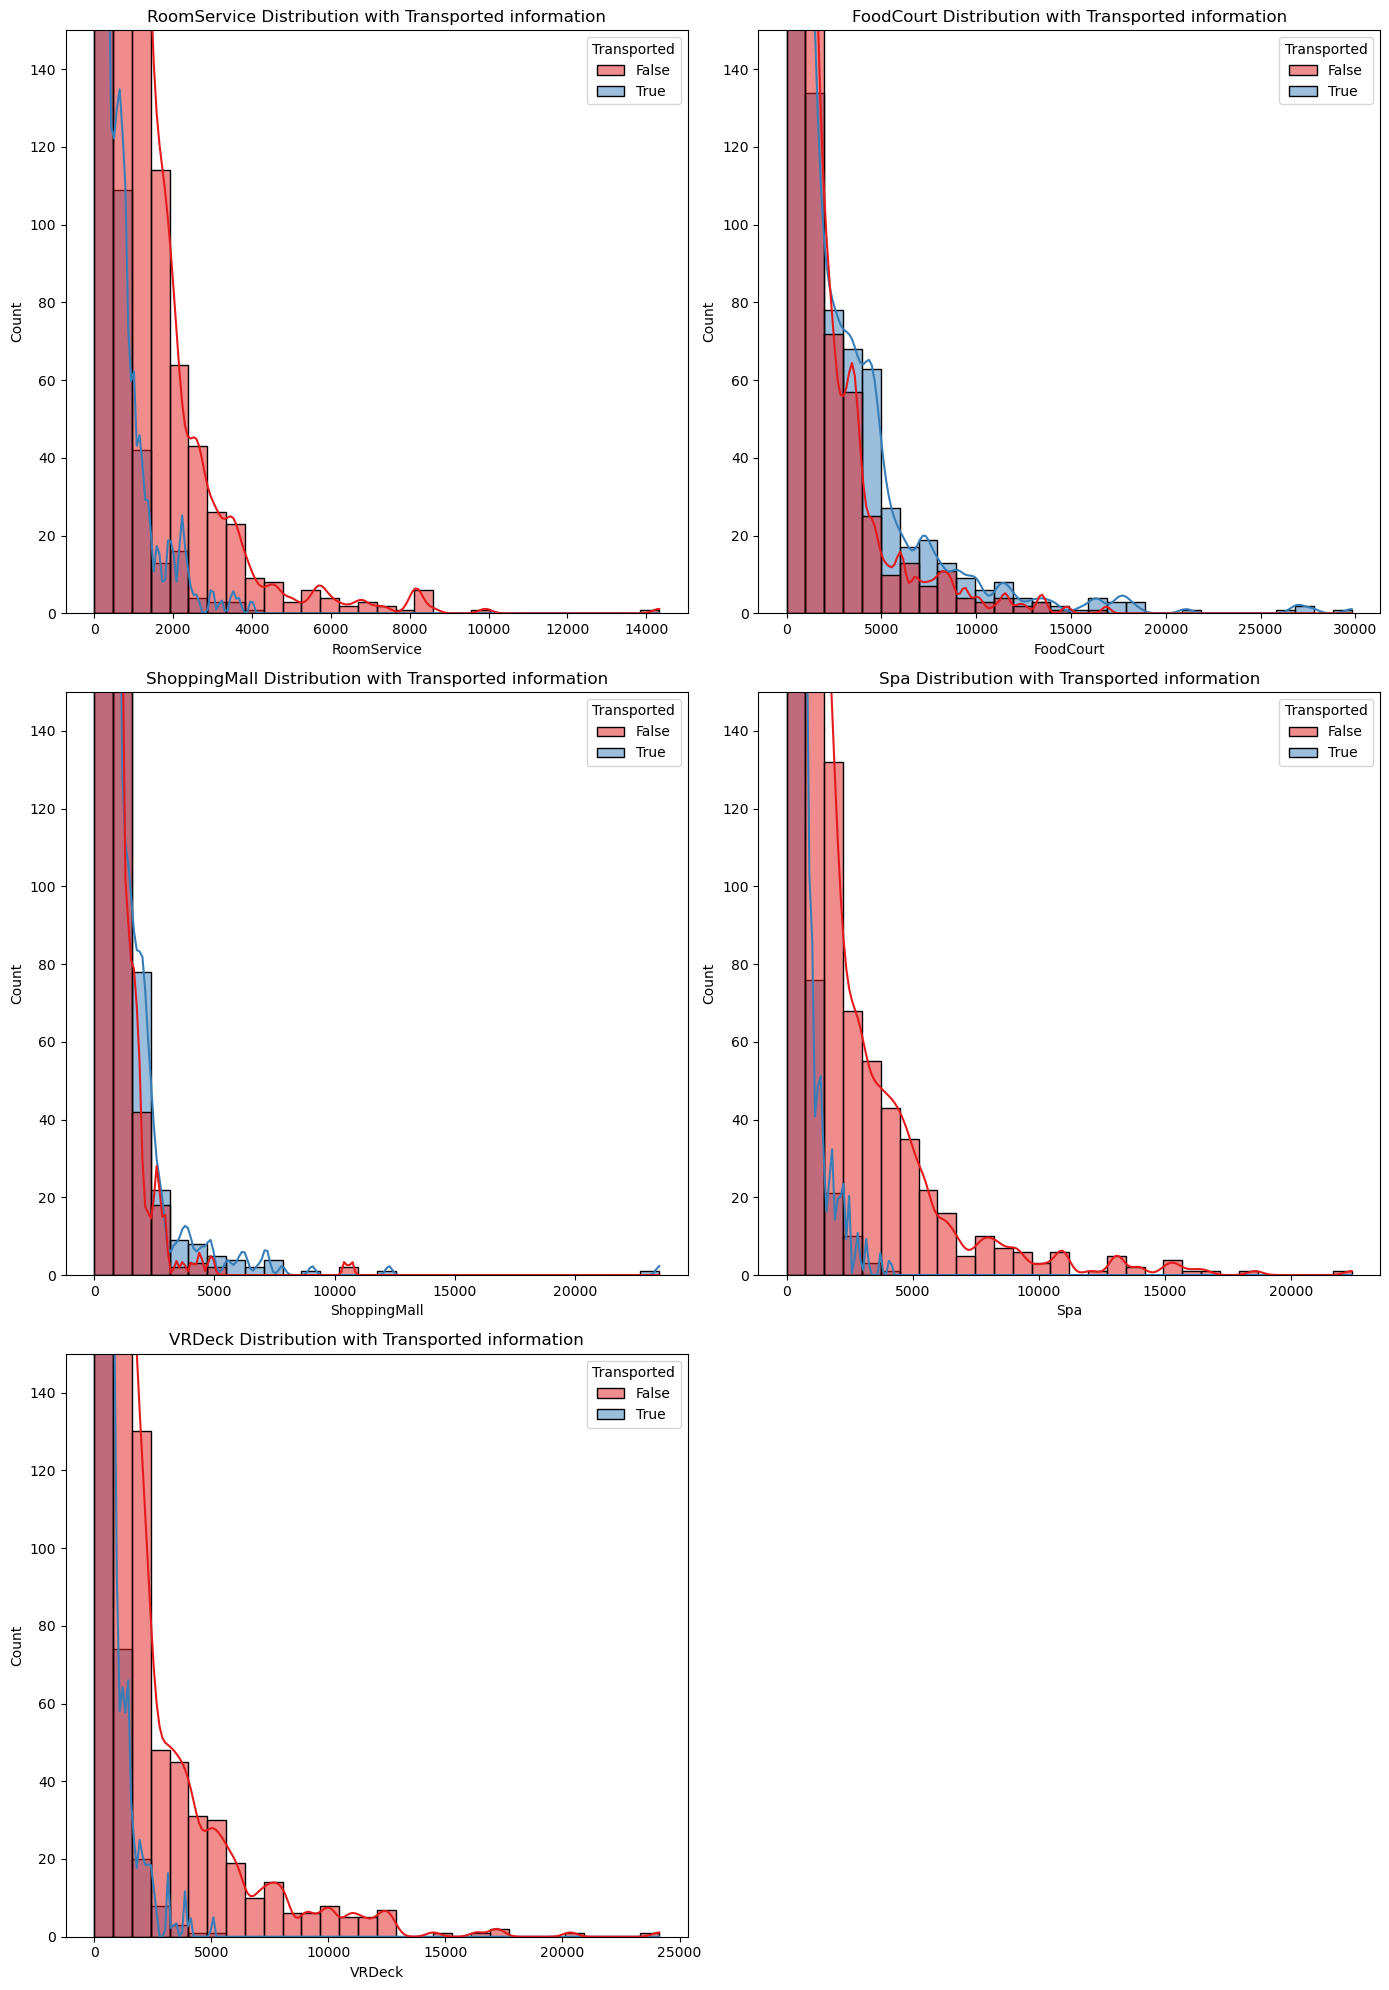

In [73]:
expenditures = ["RoomService","FoodCourt","ShoppingMall","Spa","VRDeck"]

plt.figure(figsize=(14,20))
for idx, column in enumerate (expenditures):
    plt.subplot(3,2,idx+1)
    sns.histplot(x=column, hue="Transported", data=train_df,
                 bins=30, kde=True, palette="Set1")
    plt.title(f"{column} Distribution with Transported information")
    plt.ylim(0,150)
    plt.tight_layout()


We can observe that most of the passengers doesn't seems to expend any money.
Since most of the expenses are 0 so the values with higher expenses are kind of outliers in our data.

roomservice , spa vrdeck similar distrib

foodcourt, shoppingmall same

all Right Skewed ==> 

Passengers having less expenses are more likely to be transported than passengers having high expenses.

---------------------------

log transformation before model building

Total expenditure indicate total expenses 

Since, most people expense is 0 so we can create a new boolean feature No Spending indicating whether the passenger total expense is 0 or not.

We can split Total Expenditure into different categories of expenditure like Low , Medium & High Expenses and create one more new feature Expenditure Category

## Visualizing Homeplanet, Cryosleep, destination, VIP

c:\Users\colin\anaconda3\envs\Alaska\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
c:\Users\colin\anaconda3\envs\Alaska\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


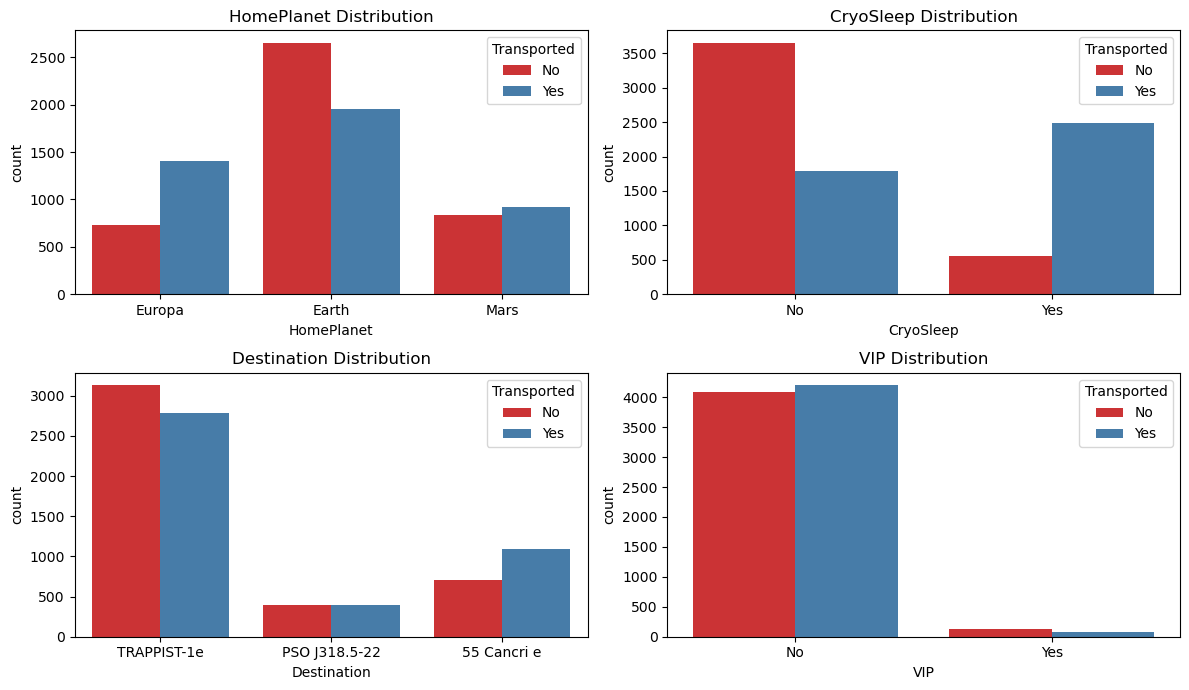

In [101]:

cat_cols = ["HomePlanet", "CryoSleep", "Destination", "VIP"]

plt.figure(figsize=(12, 7))  # Ajustez la taille de la figure pour mieux correspondre à un affichage carré

for idx, column in enumerate(cat_cols):
    plt.subplot(2, 2, idx + 1)  # Changez ici pour 2 lignes et 2 colonnes
    sns.countplot(x=column, hue="Transported", data=train_df, palette="Set1")
    plt.title(f"{column} Distribution")
    plt.legend(title='Transported', loc='upper right')  # Ajustez la légende si nécessaire

plt.tight_layout()  # Ajustez l'agencement pour éviter le chevauchement
plt.show()


In HomePlanet feature we can observe that most of passenger are from Earth but passenger from Earth are Comparatively Less Transported, passenger from Mars are Equally Transported, and passengers from Europa are Highly Transported.

In Destination feature we can observe that most of the passengers are transported to Trappist-1e.

In VIP feature we can observe that one cateogry is dominating other category too much. So it doesn't seem to be usefull feature because it can lead to overfitting in our model.

So it's better to drop VIP feature before Model building

--------------
We have visualized all the features expect PassengerId, Name, Cabin features. We can't visualize this features because they are having high cardinality.


# Feature Engineering

## PassengerId

In [75]:
train_df["PassengerId"].to_frame().head()

,PassengerId
0,0001_01
1,0002_01
2,0003_01
3,0003_02
4,0004_01


We can create a new feature Group_Size which will indicate total number of members present in each group.

feature Travelling Solo indicating whether the passenger is travelling solo or in a group.

In [76]:
def passagerid_new_features(df):
    df["Group"] = df["PassengerId"].apply(lambda x: x.split("_")[0])
    df["Member"] = df["PassengerId"].apply(lambda x: x.split("_")[1])

    # grouping the group feature with respect to "member" feature to check
    # which group is travelling with how many member 

    x = df.groupby("Group")["Member"].count()

    # creating a set of group values which are travelling with more than 1 member
    y = set(x[x>1].index)

    df["Travelling_Solo"] = df["Group"].apply(lambda x : x not in y)

    #creating a new feature "group_size" which will indicate each group nb of members

    df["Group_size"] = 0
    for i in x.items():
        df.loc[df["Group"]==i[0],"Group_size"] = i[1]


passagerid_new_features(train_df)
passagerid_new_features(test_df)
train_df

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported,Group,Member,Travelling_Solo,Group_size
0,0001_01,Europa,No,B/0/P,TRAPPIST-1e,39.0,No,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,No,0001,01,True,1
1,0002_01,Earth,No,F/0/S,TRAPPIST-1e,24.0,No,109.0,9.0,25.0,549.0,44.0,Juanna Vines,Yes,0002,01,True,1
2,0003_01,Europa,No,A/0/S,TRAPPIST-1e,58.0,Yes,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,No,0003,01,False,2
3,0003_02,Europa,No,A/0/S,TRAPPIST-1e,33.0,No,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,No,0003,02,False,2
4,0004_01,Earth,No,F/1/S,TRAPPIST-1e,16.0,No,303.0,70.0,151.0,565.0,2.0,Willy Santantines,Yes,0004,01,True,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,9276_01,Europa,No,A/98/P,55 Cancri e,41.0,Yes,0.0,6819.0,0.0,1643.0,74.0,Gravior Noxnuther,No,9276,01,True,1
8689,9278_01,Earth,Yes,G/1499/S,PSO J318.5-22,18.0,No,0.0,0.0,0.0,0.0,0.0,Kurta Mondalley,No,9278,01,True,1
8690,9279_01,Earth,No,G/1500/S,TRAPPIST-1e,26.0,No,0.0,0.0,1872.0,1.0,0.0,Fayey Connon,Yes,9279,01,True,1
8691,9280_01,Europa,No,E/608/S,55 Cancri e,32.0,No,0.0,1049.0,0.0,353.0,3235.0,Celeon Hontichre,No,9280,01,False,2


In [77]:
train_df.drop(columns=["Group","Member"],inplace=True)
test_df.drop(columns=["Group","Member"],inplace=True)

visualizing "group_size" & "travelling_solo"

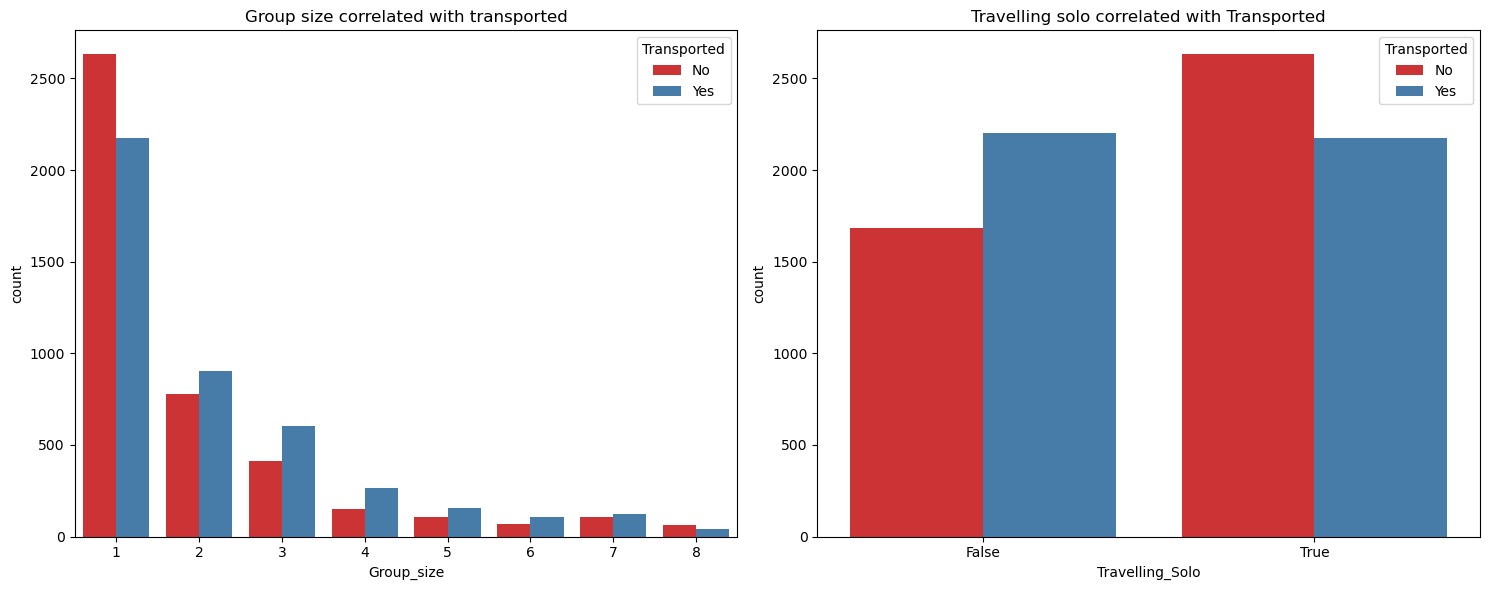

In [78]:
plt.figure(figsize=(15,6))
plt.subplot(1,2,1)
sns.countplot(x="Group_size", hue="Transported" ,data=train_df, palette="Set1")
plt.title("Group size correlated with transported")

plt.subplot(1,2,2)
sns.countplot(x="Travelling_Solo", hue="Transported", data=train_df, palette="Set1")
plt.title("Travelling solo correlated with Transported")
plt.tight_layout()
plt.show()

From Group_Size feature we can observe that most the passengers are travelling alone.

From Travelling_Solo feature we can observe that passengers travelling solo are comparatively less transported when compared with passenger travelling in group.

## New Feature from "Cabin"

In [79]:
train_df["Cabin"].head().to_frame()

,Cabin
0,B/0/P
1,F/0/S
2,A/0/S
3,A/0/S
4,F/1/S


deck/number/side

In [80]:
def cabin_new_feature(df):
    df["Cabin"].fillna("np.nan/np.nan/np.nan",inplace=True)  #In this way we can split NaN values into all three categories
    
    df["Cabin_Deck"] = df["Cabin"].apply(lambda x: x.split("/")[0])
    df["Cabin_Number"]  = df["Cabin"].apply(lambda x: x.split("/")[1])
    df["Cabin_Side"] = df["Cabin"].apply(lambda x: x.split("/")[2])
    
    #Replacing string nan values to numpy nan values..
    cols = ["Cabin_Deck","Cabin_Number","Cabin_Side"]
    df[cols]=df[cols].replace("np.nan",np.nan)
    
    #Filling Missing Values in new features created. a refaire
    # mode() most frequent value
    df["Cabin_Deck"].fillna(df["Cabin_Deck"].mode()[0],inplace=True)
    df["Cabin_Side"].fillna(df["Cabin_Side"].mode()[0],inplace=True)
    df["Cabin_Number"].fillna(df["Cabin_Number"].median(),inplace=True)

cabin_new_feature(train_df)
cabin_new_feature(test_df)

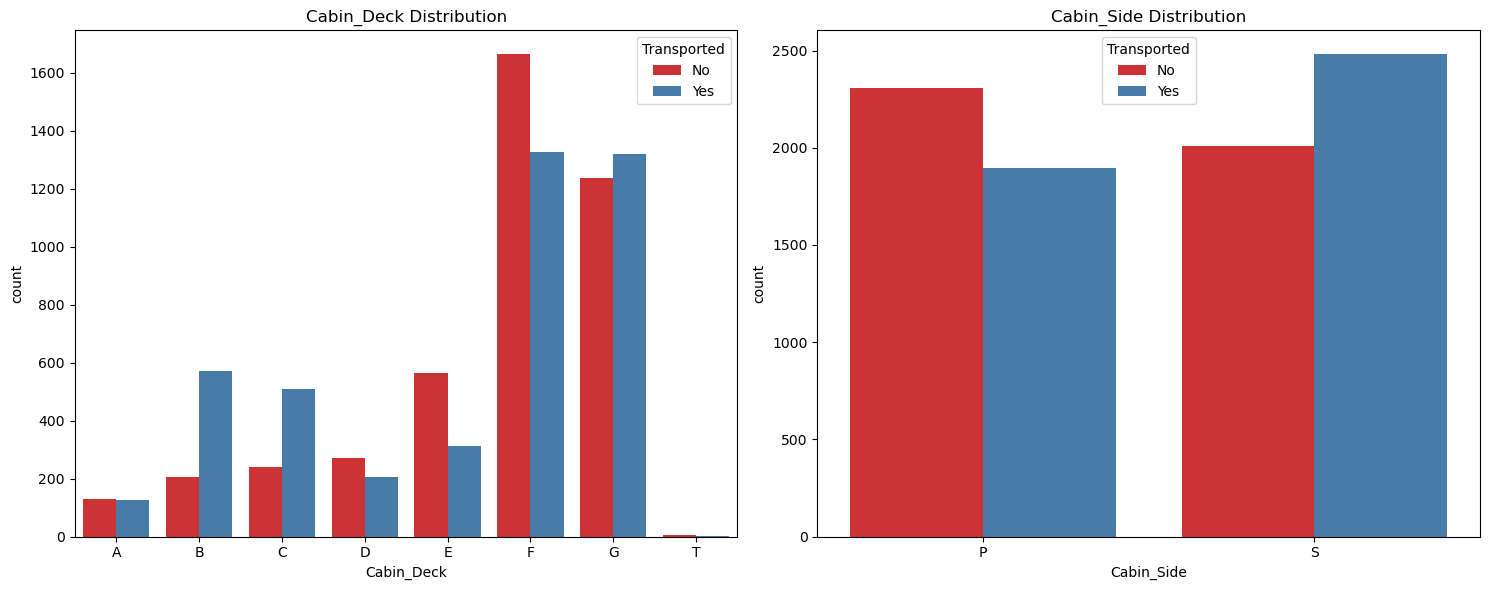

In [81]:
# Cabin_deck distribution
plt.figure(figsize=(15,6))
plt.subplot(1,2,1)
sns.countplot(x="Cabin_Deck",hue="Transported", data=train_df, palette="Set1",order=["A","B","C","D","E","F","G","T"])
plt.title("Cabin_Deck Distribution")

plt.subplot(1,2,2)
sns.countplot(x="Cabin_Side", hue="Transported", data=train_df, palette="Set1")
plt.title("Cabin_Side Distribution")
plt.tight_layout()
plt.show()

From Cabin_Deck we can observe that most of the people are from F & G Deck.
 There are very few passengers in Cabin_Deck ,T.
 Passengers from Cabin Deck B & C are very highly transported.

From Cabin_Side we can observe that almost half passengers were from cabin side S and half from cabin side P.
But passenger from cabin_side S are Highly Transported but passengers from cabin_side P are Equally Transported

deck number visual

Total Unique values present in Cabin_Number feature is: 1817
The Mean of Cabin_Number Feature is:  596.3989416772115
The Median of Cabin_Number Feature is: 427.0
The Minimum value of Cabin_Number feature is: 0
The Maximum value of Cabin_number Feature is: 1894


c:\Users\colin\anaconda3\envs\Alaska\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\colin\anaconda3\envs\Alaska\Lib\site-packages\seaborn\_oldcore.py:1057: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = data.groupby(


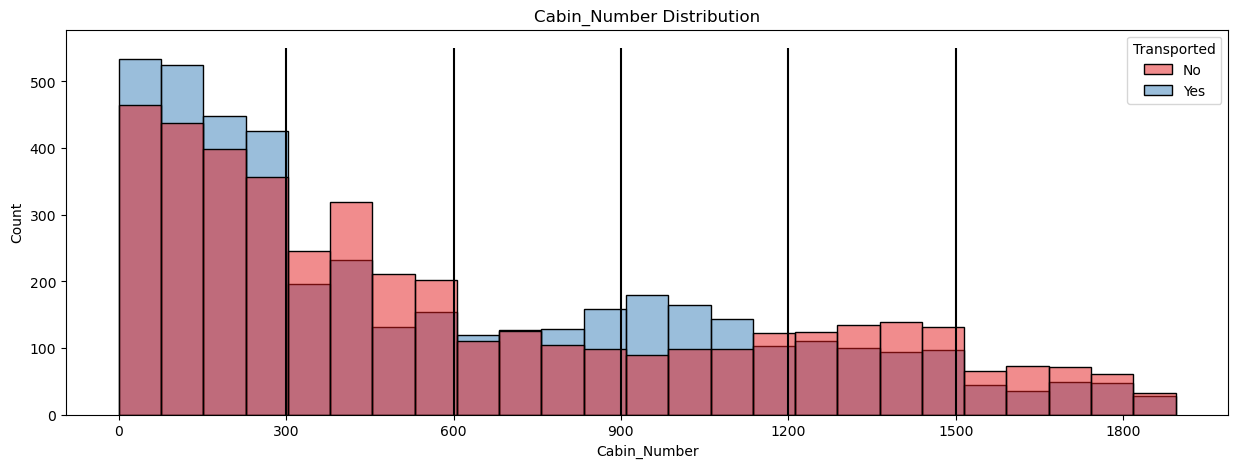

In [82]:
train_df["Cabin_Number"] = train_df["Cabin_Number"].astype(int)
test_df["Cabin_Number"] = test_df["Cabin_Number"].astype(int)

print("Total Unique values present in Cabin_Number feature is:",train_df["Cabin_Number"].nunique())
print("The Mean of Cabin_Number Feature is: ",train_df["Cabin_Number"].mean())
print("The Median of Cabin_Number Feature is:",train_df["Cabin_Number"].median())
print("The Minimum value of Cabin_Number feature is:",train_df["Cabin_Number"].min())
print("The Maximum value of Cabin_number Feature is:",train_df["Cabin_Number"].max())

plt.figure(figsize=(15,5))
sns.histplot(x="Cabin_Number",data=train_df,hue="Transported",palette="Set1")
plt.title("Cabin_Number Distribution")
plt.xticks(list(range(0,1900,300)))
plt.vlines(300,ymin=0,ymax=550,color="black")
plt.vlines(600,ymin=0,ymax=550,color="black")
plt.vlines(900,ymin=0,ymax=550,color="black")
plt.vlines(1200,ymin=0,ymax=550,color="black")
plt.vlines(1500,ymin=0,ymax=550,color="black")
plt.show()


In [83]:
def cabin_regions(df):
    df["Cabin_Region1"] = (df["Cabin_Number"]<300)
    df["Cabin_Region2"] = (df["Cabin_Number"]>=300) & (df["Cabin_Number"]<600)
    df["Cabin_Region3"] = (df["Cabin_Number"]>=600) & (df["Cabin_Number"]<900)
    df["Cabin_Region4"] = (df["Cabin_Number"]>=900) & (df["Cabin_Number"]<1200)
    df["Cabin_Region5"] = (df["Cabin_Number"]>=1200) & (df["Cabin_Number"]<1500)
    df["Cabin_Region6"] = (df["Cabin_Number"]>=1500)

cabin_regions(train_df)
cabin_regions(test_df)
train_df.drop(columns=["Cabin_Number"],inplace=True)
test_df.drop(columns=["Cabin_Number"],inplace=True)

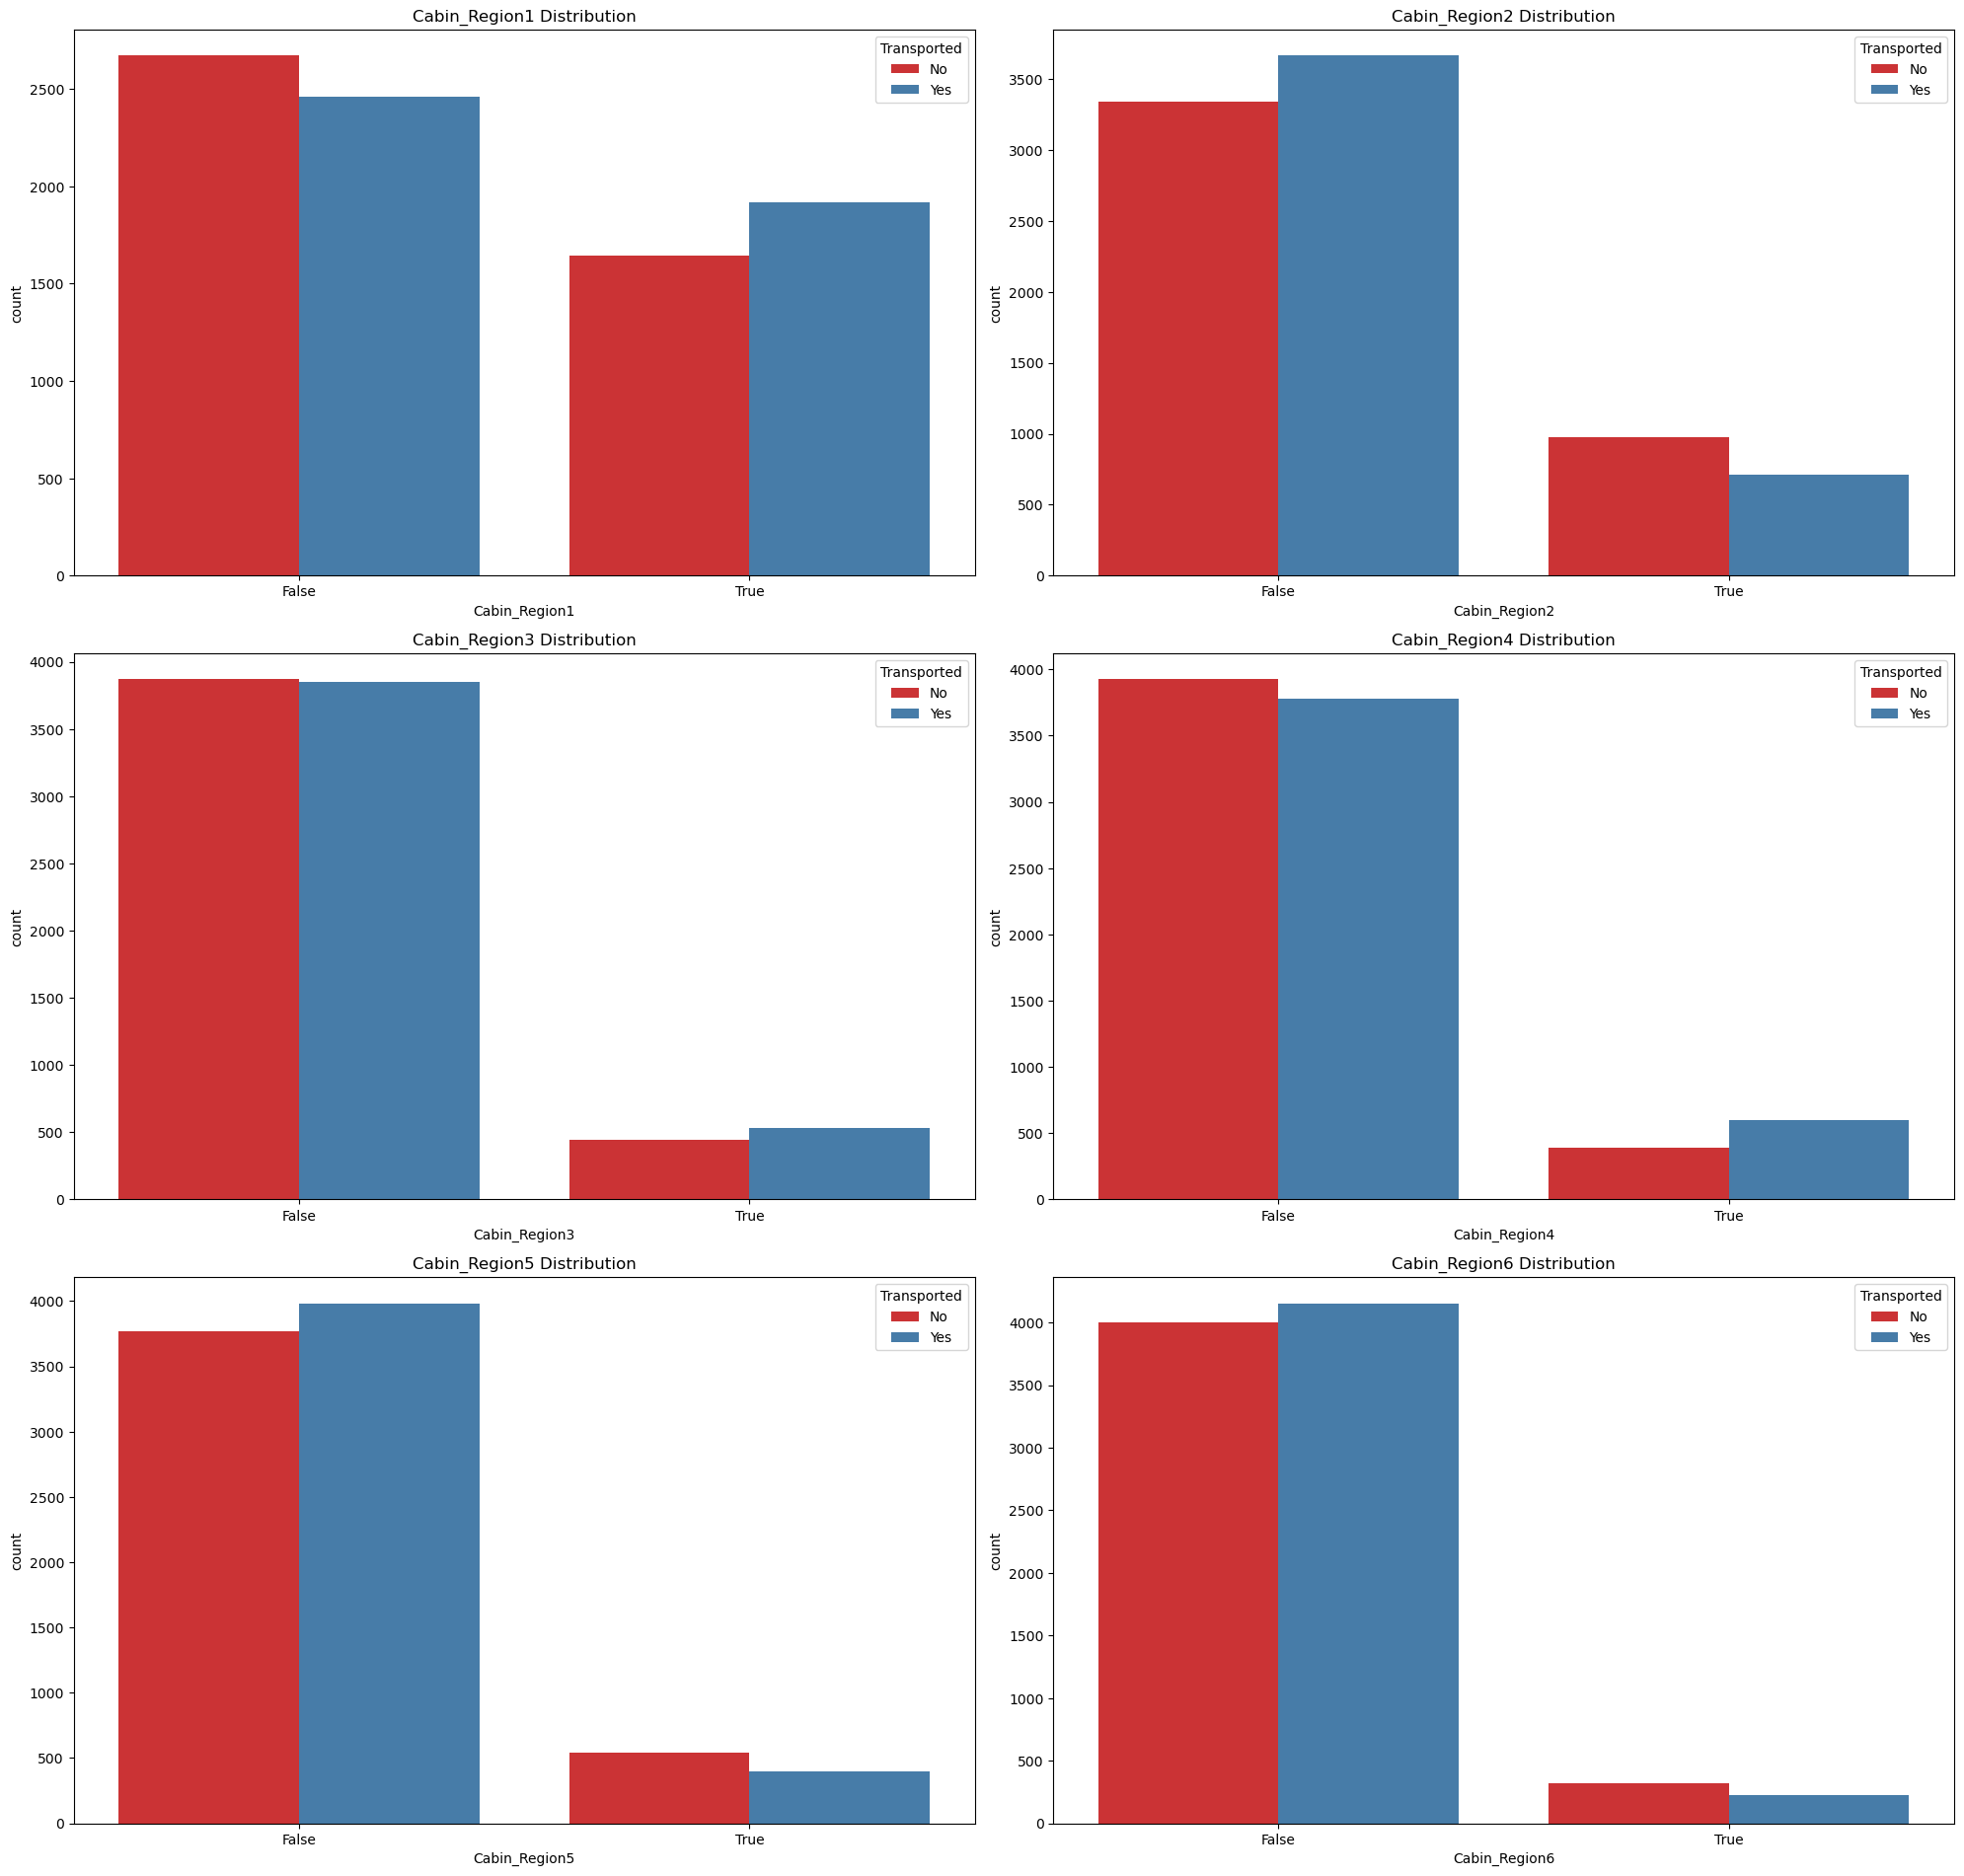

In [84]:
# visualizing "cabin_region"
cols = ["Cabin_Region1","Cabin_Region2","Cabin_Region3","Cabin_Region4","Cabin_Region5","Cabin_Region6"]

plt.figure(figsize=(20,25))
for idx, value in enumerate(cols):
    plt.subplot(4,2,idx+1)
    sns.countplot(x=value, hue="Transported", data=train_df, palette="Set1")
    plt.title(f"{value} Distribution")
    plt.tight_layout()


Cabin_Region1 are Highly Transported when compared with other cabin regions.

Cabin region number is increasing passengers transport is decreasing

## Feature from Age

Text(0.5, 1.0, 'Age Group Distribution')

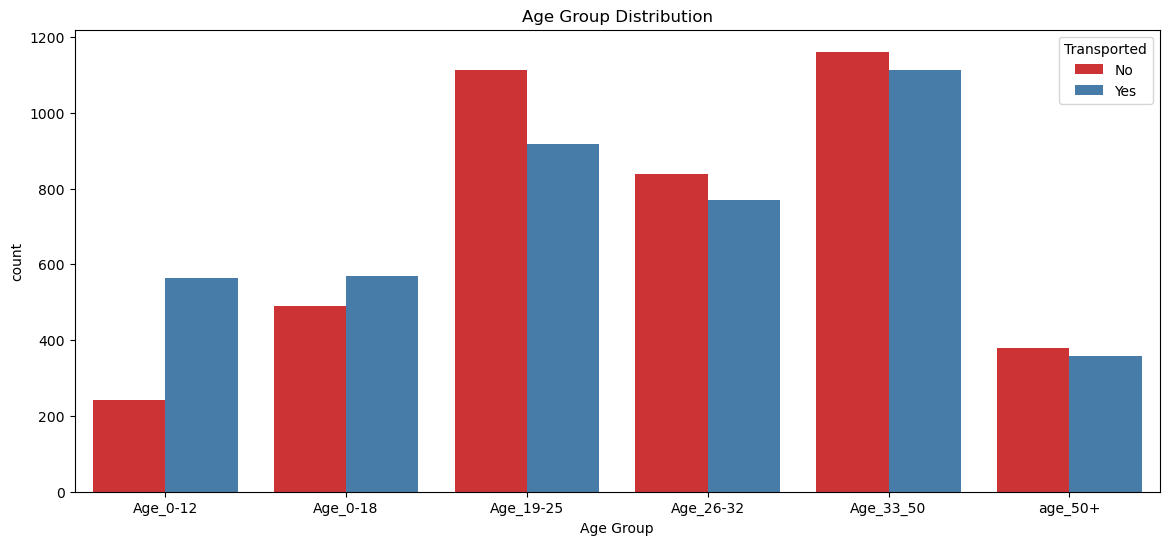

In [85]:
def age_group(df):
    age_group  = []
    for i in df["Age"]:
        if i<=12:
            age_group.append("Age_0-12")
        elif (i>12 and i<=18):
            age_group.append("Age_0-18")
        elif (i>18 and i<=25):
            age_group.append("Age_19-25")
        elif (i>25 and i<=32):
            age_group.append("Age_26-32")
        elif (i>32 and i<=50):
            age_group.append("Age_33_50")
        elif (i>50):
            age_group.append("age_50+")
        else:
            age_group.append(np.nan)
        
    df["Age Group"] = age_group
age_group(train_df)
age_group(test_df)

order = sorted(train_df["Age Group"].value_counts().keys().to_list())

plt.figure(figsize=(14,6))
sns.countplot(x="Age Group",hue="Transported", data=train_df, palette="Set1",order=order)
plt.title("Age Group Distribution")


This new feature looks more relevent to our target data.

Age_0-12 & Age_0-18 are more likely to be transported compared to not transported.

Age_19-25 , Age_26_32 & Age_33_50 are less likely to be transported compared to not transported.

Age_50+ are almost equally transported compared to not transported.

## New Features with expenditude

In [86]:
exp_cols = ["RoomService","FoodCourt","ShoppingMall","Spa","VRDeck"]
train_df[exp_cols]

,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
0,0.0,0.0,0.0,0.0,0.0
1,109.0,9.0,25.0,549.0,44.0
2,43.0,3576.0,0.0,6715.0,49.0
3,0.0,1283.0,371.0,3329.0,193.0
4,303.0,70.0,151.0,565.0,2.0
...,...,...,...,...,...
8688,0.0,6819.0,0.0,1643.0,74.0
8689,0.0,0.0,0.0,0.0,0.0
8690,0.0,0.0,1872.0,1.0,0.0
8691,0.0,1049.0,0.0,353.0,3235.0


c:\Users\colin\anaconda3\envs\Alaska\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\colin\anaconda3\envs\Alaska\Lib\site-packages\seaborn\_oldcore.py:1057: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = data.groupby(


Mean value of Total Expenditure feature is =  1441
Median value of Total Expenditure feature is =  716.0


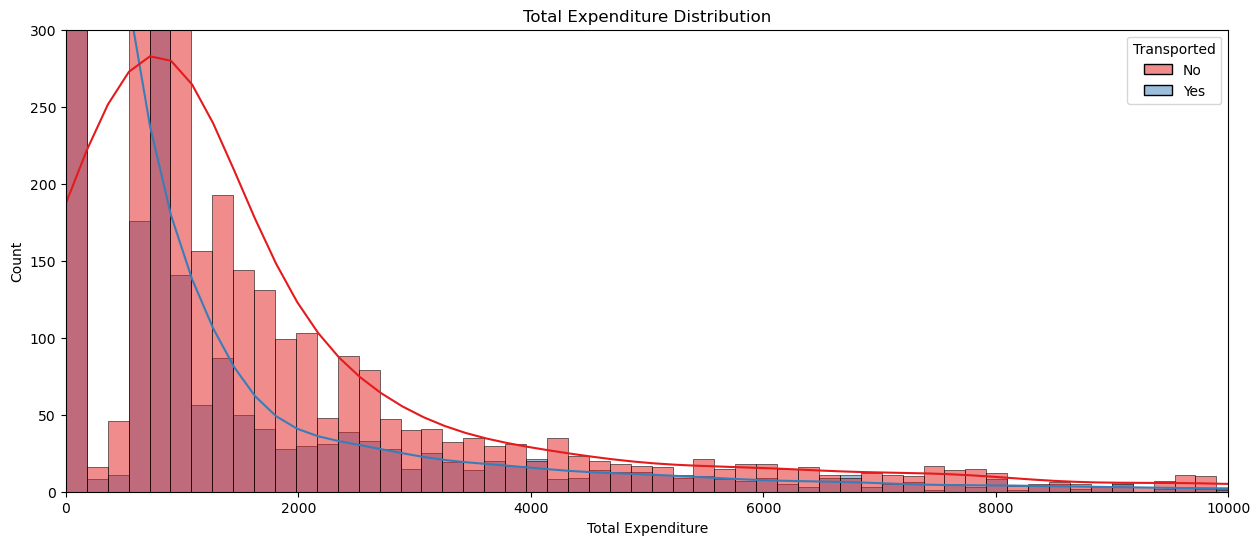

In [87]:
def new_exp_features(df):
    df["Total Expenditure"] = df[exp_cols].sum(axis=1)
    df["No Spending"] = (df["Total Expenditure"]==0)
new_exp_features(train_df)
new_exp_features(test_df)

plt.figure(figsize=(15,6))
sns.histplot(x="Total Expenditure", hue="Transported", data=train_df, kde=True, palette="Set1",bins=200)
plt.ylim(0,300)
plt.xlim(0,10000)
plt.title("Total Expenditure Distribution")

mean = round(train_df["Total Expenditure"].mean())
median = train_df["Total Expenditure"].median()


print("Mean value of Total Expenditure feature is = ",mean)
print("Median value of Total Expenditure feature is = ",median)

In [88]:
def expenditure_category(df):
    expense_category = []   
    for i in df["Total Expenditure"]:
        if i==0:
            expense_category.append("No Expense")
        elif (i>0 and i<=716):
            expense_category.append("Low Expense")
        elif (i>716 and i<=1441):
            expense_category.append("Medium Expense")
        elif (i>1441):
            expense_category.append("High Expense")

    
    df["Expenditure Category"] = expense_category

expenditure_category(train_df)
expenditure_category(test_df)


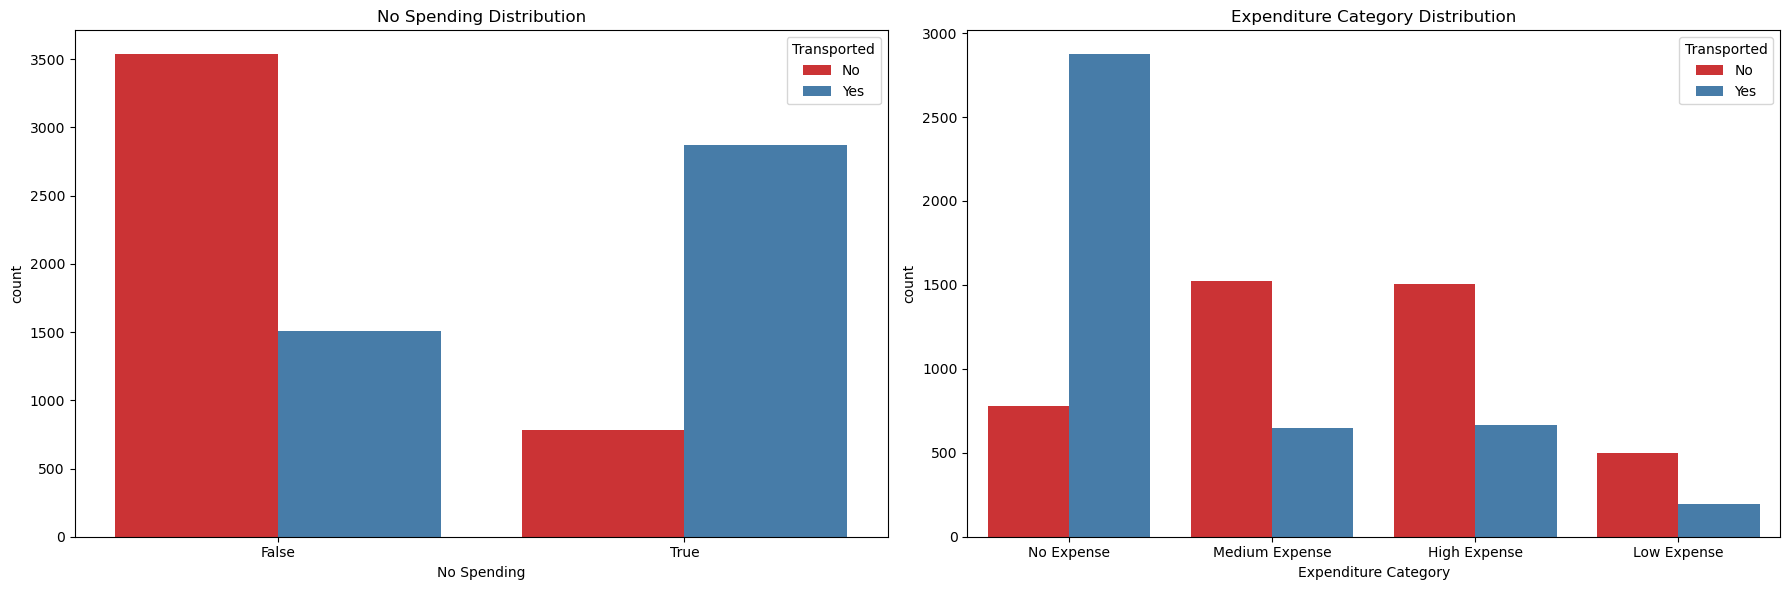

In [89]:
#visualization 
cols = ["No Spending", "Expenditure Category"]

plt.figure(figsize=(18,6))
for idx,column in enumerate(cols):
    plt.subplot(1,2,idx+1)
    sns.countplot(x=column, hue="Transported", data=train_df, palette="Set1")
    plt.title(f"{column} Distribution")
    plt.tight_layout()

In Total Expenditure feature we can observe that passengers having low total expenses are likely to be transported more.

In No Spending feature we can observe that passenger having No Spending are highly transported.

Expenditure Category feature we can confirm than passenger having No Expense are highly transported 

# Data pre-processing

In [90]:
z = train_df.isnull().sum()[train_df.isnull().sum()>0].to_frame().rename(columns={0:"No. of Missing values"})
z["% of Missing values"] = round(train_df.isnull().sum()[train_df.isnull().sum()>0]*100/len(train_df),2)
z

,No. of Missing values,% of Missing values
HomePlanet,201,2.31
CryoSleep,217,2.50
Destination,182,2.09
Age,179,2.06
VIP,203,2.34
RoomService,181,2.08
FoodCourt,183,2.11
ShoppingMall,208,2.39
Spa,183,2.11
VRDeck,188,2.16


handling missing values

In [91]:
cat_cols = train_df.select_dtypes(include=["object","bool"]).columns.tolist()
cat_cols.remove("Transported")
num_cols = train_df.select_dtypes(include=["int","float"]).columns.tolist()

ValueError: list.remove(x): x not in list

In [ ]:
print("Categorical Columns: ",cat_cols)
print("\n","-"*120)
print("\nNumerical Columns: ",num_cols)

Categorical Columns:  ['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'VIP', 'Name', 'Travelling_Solo', 'Cabin_Deck', 'Cabin_Side', 'Cabin_Region1', 'Cabin_Region2', 'Cabin_Region3', 'Cabin_Region4', 'Cabin_Region5', 'Cabin_Region6', 'Age Group', 'No Spending', 'Expenditure Category']

 ------------------------------------------------------------------------------------------------------------------------

Numerical Columns:  ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Group_size', 'Total Expenditure']


In [ ]:
# fill categorical feature
imputer1 = SimpleImputer(strategy="most_frequent")
# fill numerical feature
imputer2 = SimpleImputer(strategy="median")

def fill_missingno(df):
    df[cat_cols] = SimpleImputer(strategy="most_frequent").fit_transform(df[cat_cols])
    df[num_cols] = SimpleImputer(strategy="median").fit_transform(df[num_cols])

fill_missingno(train_df)
fill_missingno(test_df)

print("Missing numbers left in train_df is: ", train_df.isnull().sum().sum())
print("Missing numbers left in test_df is: ", test_df.isnull().sum())

Missing numbers left in train_df is:  0
Missing numbers left in test_df is:  PassengerId             0
HomePlanet              0
CryoSleep               0
Cabin                   0
Destination             0
Age                     0
VIP                     0
RoomService             0
FoodCourt               0
ShoppingMall            0
Spa                     0
VRDeck                  0
Name                    0
Travelling_Solo         0
Group_size              0
Cabin_Deck              0
Cabin_Side              0
Cabin_Region1           0
Cabin_Region2           0
Cabin_Region3           0
Cabin_Region4           0
Cabin_Region5           0
Cabin_Region6           0
Age Group               0
Total Expenditure       0
No Spending             0
Expenditure Category    0
dtype: int64


In [ ]:
print("Duplicate values in training data is: ",train_df.duplicated().sum())
print("Duplicate values in testing data is: ",test_df.duplicated().sum())

Duplicate values in training data is:  0
Duplicate values in testing data is:  0


In [ ]:
print("Cardinality of features in numerical data is: ")
print(train_df.select_dtypes(include=["object"]).nunique())
print("\n","-"*50)
print("\nCardinality of features in categorical data is: ")
print(test_df.select_dtypes(include=["object"]).nunique())

Cardinality of features in numerical data is: 
PassengerId             8693
HomePlanet                 3
CryoSleep                  2
Cabin                   6561
Destination                3
VIP                        2
Name                    8473
Travelling_Solo            2
Cabin_Deck                 8
Cabin_Side                 2
Cabin_Region1              2
Cabin_Region2              2
Cabin_Region3              2
Cabin_Region4              2
Cabin_Region5              2
Cabin_Region6              2
Age Group                  6
No Spending                2
Expenditure Category       4
dtype: int64

 --------------------------------------------------

Cardinality of features in categorical data is: 
PassengerId             4277
HomePlanet                 3
CryoSleep                  2
Cabin                   3266
Destination                3
VIP                        2
Name                    4176
Travelling_Solo            2
Cabin_Deck                 8
Cabin_Side               

 We have done all feature engineering now we can drop features which have high cardinality.

In [ ]:
##Extracting passengerId from test data because we need this for submitting our predictions on kaggle.
pass_df = test_df[["PassengerId"]]

In [ ]:
cols = ["PassengerId","Cabin","Name"]
train_df.drop(columns =cols, inplace=True)
test_df.drop(columns=cols, inplace=True)

## gathering stat info of numerical features

In [ ]:
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,8693.0,28.790291,14.341404,0.0,20.0,27.0,37.0,79.0
RoomService,8693.0,220.009318,660.519050,0.0,0.0,0.0,41.0,14327.0
FoodCourt,8693.0,448.434027,1595.790627,0.0,0.0,0.0,61.0,29813.0
ShoppingMall,8693.0,169.572300,598.007164,0.0,0.0,0.0,22.0,23492.0
Spa,8693.0,304.588865,1125.562559,0.0,0.0,0.0,53.0,22408.0
VRDeck,8693.0,298.261820,1134.126417,0.0,0.0,0.0,40.0,24133.0
Group_size,8693.0,2.035546,1.596347,1.0,1.0,1.0,3.0,8.0
Total Expenditure,8693.0,1440.866329,2803.045694,0.0,0.0,716.0,1441.0,35987.0


Obervation
💡 We can oberve in RoomService, FoodCourt, ShoppingMall, Spa & VRDeck more than 50 percentile of data are equal to 0.
💡 And when we did EDA on this features all of them were having right skewed distribution
💡 So we can simply say there is a presence of large amount of outliers in these features.
💡 So we can tranform these features to normal distribution using Log Transformation.
💡 Since, we are applying log transformation on these expenditure features so we have to apply transformation on Total Expenditure also.
💡 So that the model can have better understanding while finding patterns.

## applying log transformation on expenditure feature

C:\Users\mkoud\AppData\Local\Temp\ipykernel_42020\1249377592.py:12: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
C:\Users\mkoud\AppData\Local\Temp\ipykernel_42020\1249377592.py:12: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
C:\Users\mkoud\AppData\Local\Temp\ipykernel_42020\1249377592.py:12: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
C:\Users\mkoud\AppData\Local\Temp\ipykernel_42020\1249377592.py:12: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
C:\Users\mkoud\AppData\Local\Temp\ipykernel_42020\1249377592.py:12: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


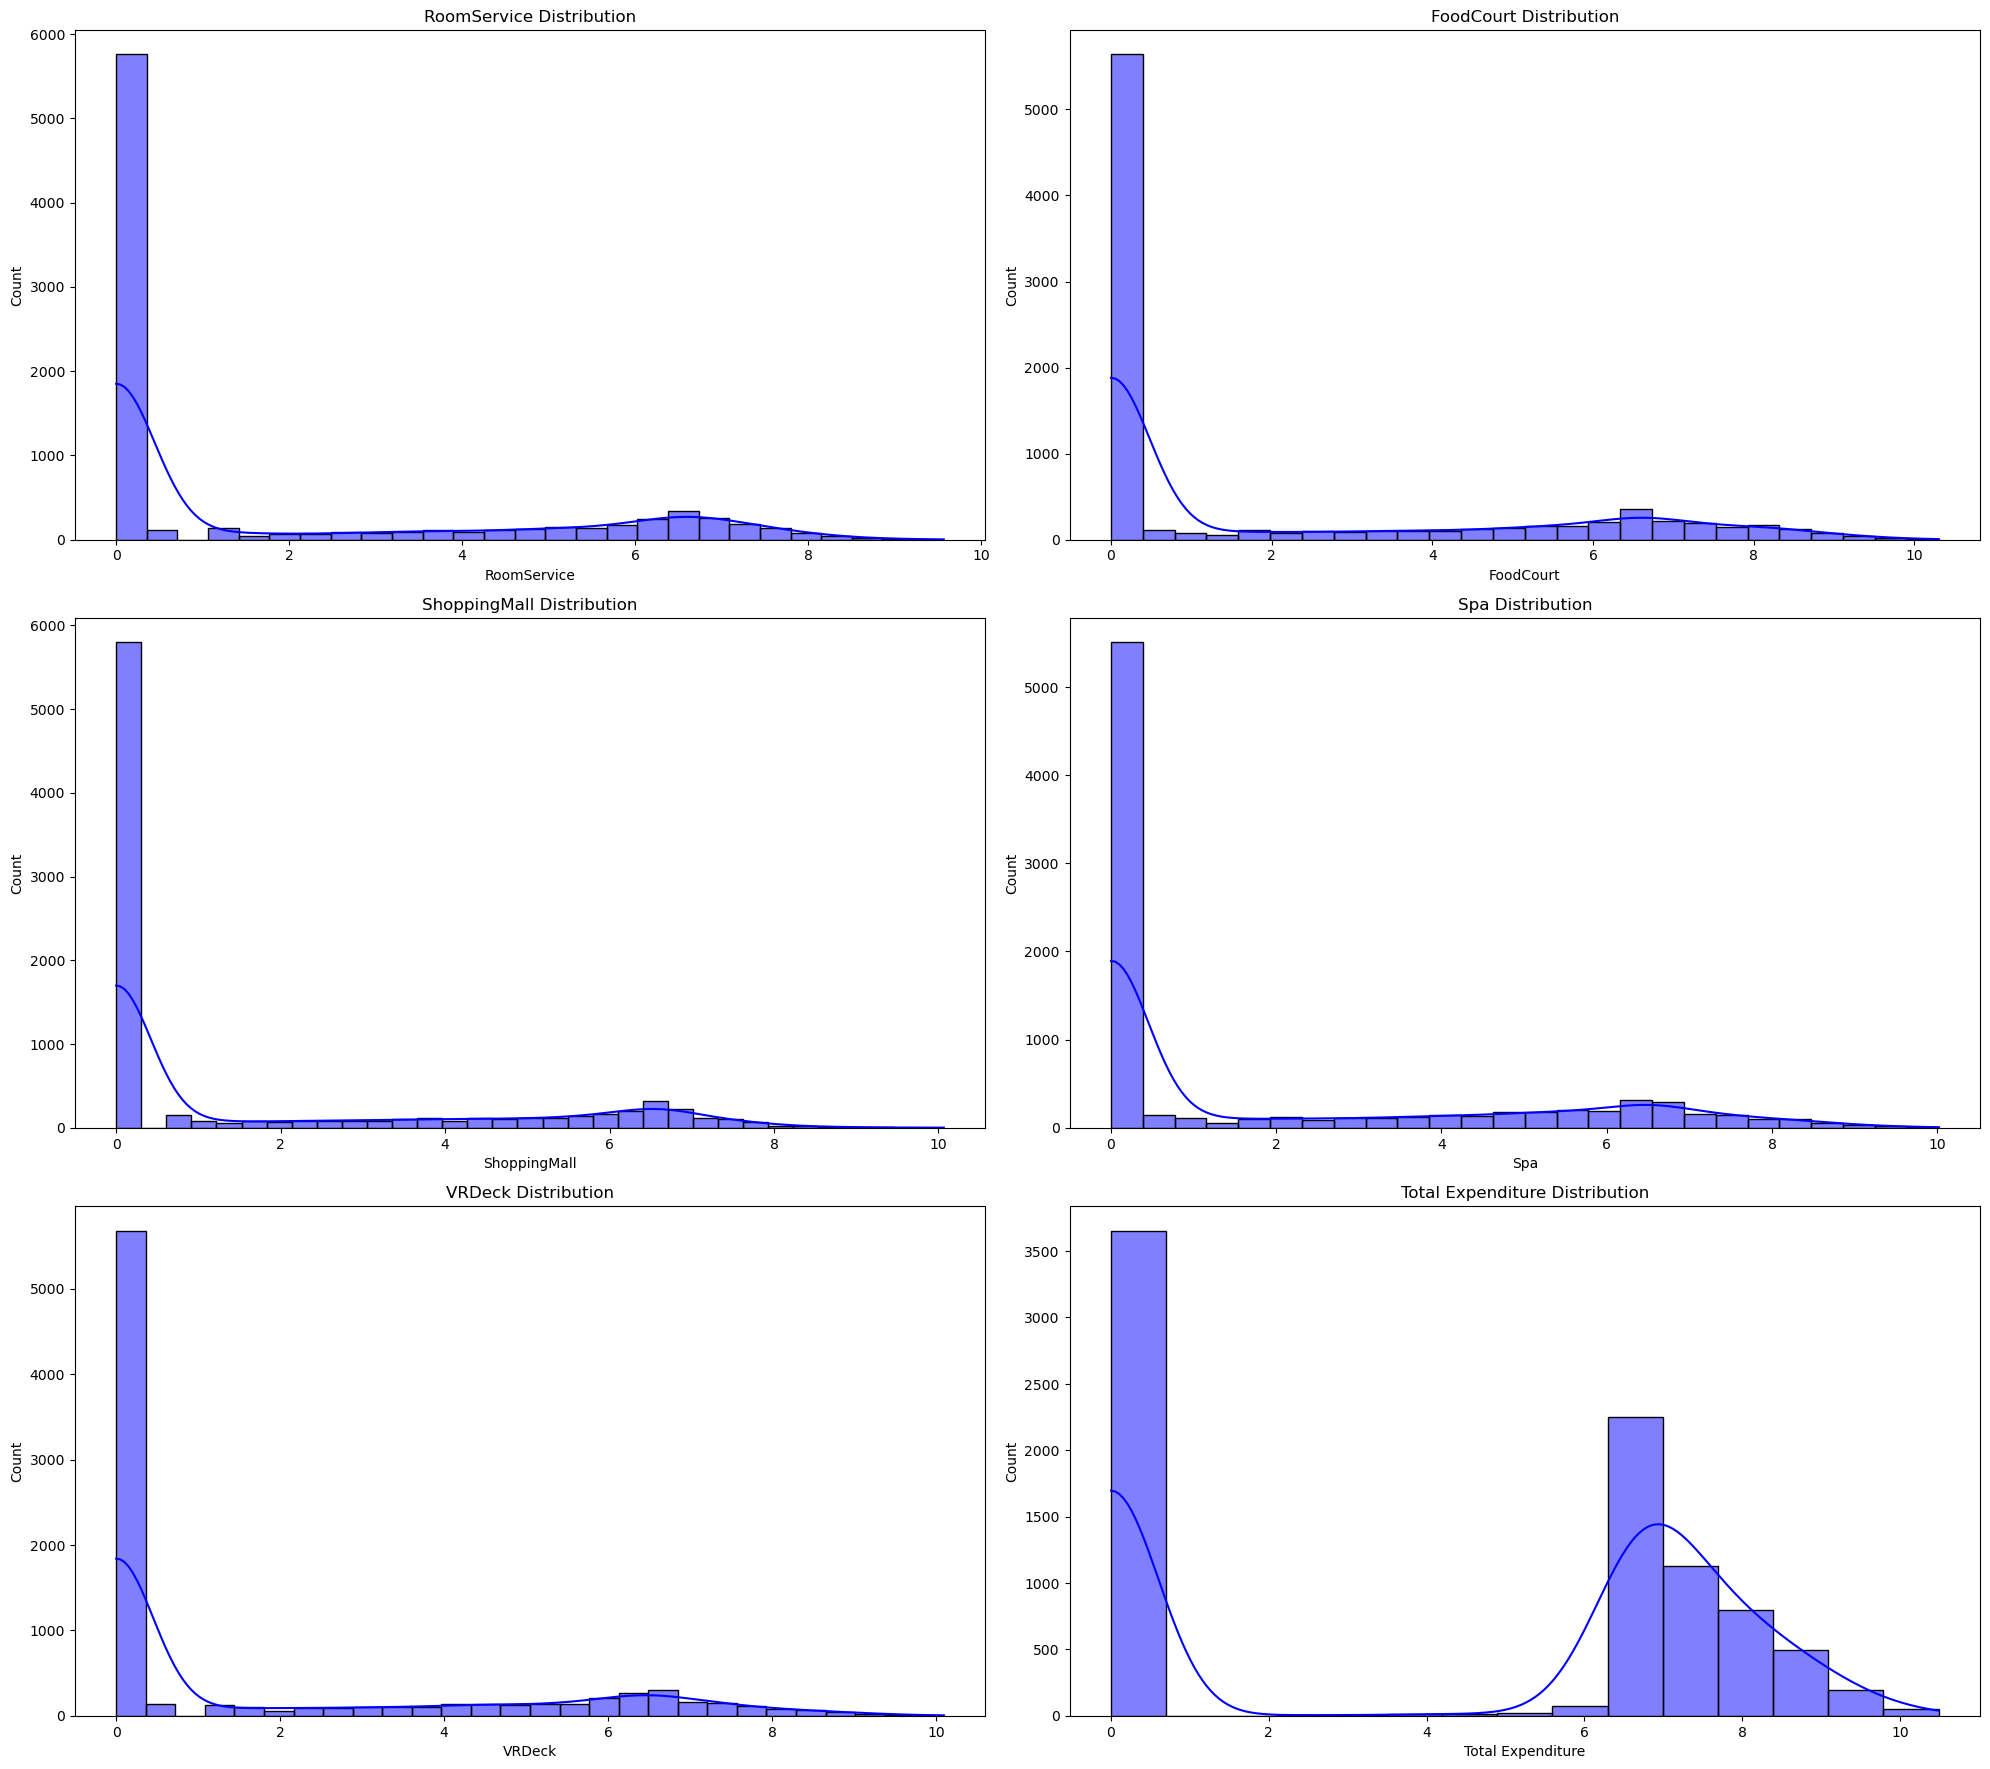

In [ ]:
cols = ['RoomService','FoodCourt','ShoppingMall','Spa','VRDeck','Total Expenditure']

for value in cols: 
    train_df[value] = np.log(1+train_df[value])
    test_df[value] = np.log(1+test_df[value])
x=1
plt.figure(figsize=(20,35))
for i in cols:
    plt.subplot(6,2,x)
    sns.histplot(train_df[i],color="blue",kde="True")
    plt.title(f"{i} Distribution")
    plt.tight_layout()

    x+=1



## check data type

In [ ]:
cols = ["CryoSleep","VIP","Travelling_Solo","No Spending","Cabin_Region1","Cabin_Region2","Cabin_Region3","Cabin_Region4",
       "Cabin_Region5","Cabin_Region6"]

train_df[cols] = train_df[cols].astype(bool)
test_df[cols] = test_df[cols].astype(bool)
train_df

,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,...,Cabin_Region1,Cabin_Region2,Cabin_Region3,Cabin_Region4,Cabin_Region5,Cabin_Region6,Age Group,Total Expenditure,No Spending,Expenditure Category
0,Europa,False,TRAPPIST-1e,39.0,False,0.000000,0.000000,0.000000,0.000000,0.000000,...,True,False,False,False,False,False,Age_33_50,0.000000,True,No Expense
1,Earth,False,TRAPPIST-1e,24.0,False,4.700480,2.302585,3.258097,6.309918,3.806662,...,True,False,False,False,False,False,Age_19-25,6.602588,False,Medium Expense
2,Europa,False,TRAPPIST-1e,58.0,True,3.784190,8.182280,0.000000,8.812248,3.912023,...,True,False,False,False,False,False,age_50+,9.248021,False,High Expense
3,Europa,False,TRAPPIST-1e,33.0,False,0.000000,7.157735,5.918894,8.110728,5.267858,...,True,False,False,False,False,False,Age_33_50,8.551981,False,High Expense
4,Earth,False,TRAPPIST-1e,16.0,False,5.717028,4.262680,5.023881,6.338594,1.098612,...,True,False,False,False,False,False,Age_0-18,6.995766,False,Medium Expense
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,Europa,False,55 Cancri e,41.0,True,0.000000,8.827615,0.000000,7.404888,4.317488,...,True,False,False,False,False,False,Age_33_50,9.052165,False,High Expense
8689,Earth,True,PSO J318.5-22,18.0,False,0.000000,0.000000,0.000000,0.000000,0.000000,...,False,False,False,False,True,False,Age_0-18,0.000000,True,No Expense
8690,Earth,False,TRAPPIST-1e,26.0,False,0.000000,0.000000,7.535297,0.693147,0.000000,...,False,False,False,False,False,True,Age_26-32,7.535830,False,High Expense
8691,Europa,False,55 Cancri e,32.0,False,0.000000,6.956545,0.000000,5.869297,8.082093,...,False,False,True,False,False,False,Age_26-32,8.442039,False,High Expense


feature encoding

nominal categorical features : One hot encoding

ordinal categorical features : LabelEncoding

In [ ]:
nominal_cat_cols_one_Hot = ["HomePlanet","Destination"]
ordinal_cat_cols_Label = ["CryoSleep","VIP","Travelling_Solo","Cabin_Deck","Cabin_Side","Cabin_Region1","Cabin_Region2",
                    "Cabin_Region3","Cabin_Region4","Cabin_Region5","Cabin_Region6","Age Group","No Spending",
                    "Expenditure Category"]


train_df[ordinal_cat_cols_Label] = train_df[ordinal_cat_cols_Label].apply(LabelEncoder().fit_transform)

test_df[ordinal_cat_cols_Label] = test_df[ordinal_cat_cols_Label].apply(LabelEncoder().fit_transform)

train_df = pd.get_dummies(train_df, columns= nominal_cat_cols_one_Hot)

test_df = pd.get_dummies(test_df, columns = nominal_cat_cols_one_Hot)


In [ ]:
print(train_df)

      CryoSleep   Age  VIP  RoomService  FoodCourt  ShoppingMall       Spa  \
0             0  39.0    0     0.000000   0.000000      0.000000  0.000000   
1             0  24.0    0     4.700480   2.302585      3.258097  6.309918   
2             0  58.0    1     3.784190   8.182280      0.000000  8.812248   
3             0  33.0    0     0.000000   7.157735      5.918894  8.110728   
4             0  16.0    0     5.717028   4.262680      5.023881  6.338594   
...         ...   ...  ...          ...        ...           ...       ...   
8688          0  41.0    1     0.000000   8.827615      0.000000  7.404888   
8689          1  18.0    0     0.000000   0.000000      0.000000  0.000000   
8690          0  26.0    0     0.000000   0.000000      7.535297  0.693147   
8691          0  32.0    0     0.000000   6.956545      0.000000  5.869297   
8692          0  44.0    0     4.844187   8.452975      0.000000  0.000000   

        VRDeck  Transported  Travelling_Solo  ...  Age Group  \

In [ ]:
train_df["Transported"].replace({False:0,True:1},inplace=True)
train_df.head()

,CryoSleep,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,Travelling_Solo,...,Age Group,Total Expenditure,No Spending,Expenditure Category,HomePlanet_Earth,HomePlanet_Europa,HomePlanet_Mars,Destination_55 Cancri e,Destination_PSO J318.5-22,Destination_TRAPPIST-1e
0,0,39.0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0,1,...,4,0.000000,1,3,False,True,False,False,False,True
1,0,24.0,0,4.700480,2.302585,3.258097,6.309918,3.806662,1,1,...,2,6.602588,0,2,True,False,False,False,False,True
2,0,58.0,1,3.784190,8.182280,0.000000,8.812248,3.912023,0,0,...,5,9.248021,0,0,False,True,False,False,False,True
3,0,33.0,0,0.000000,7.157735,5.918894,8.110728,5.267858,0,0,...,4,8.551981,0,0,False,True,False,False,False,True
4,0,16.0,0,5.717028,4.262680,5.023881,6.338594,1.098612,1,1,...,1,6.995766,0,2,True,False,False,False,False,True


In [ ]:
test_df.head()

,CryoSleep,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Travelling_Solo,Group_size,...,Age Group,Total Expenditure,No Spending,Expenditure Category,HomePlanet_Earth,HomePlanet_Europa,HomePlanet_Mars,Destination_55 Cancri e,Destination_PSO J318.5-22,Destination_TRAPPIST-1e
0,1,27.0,0,0.000000,0.000000,0.000000,0.000000,0.00000,1,1.0,...,3,0.000000,1,3,True,False,False,False,False,True
1,0,19.0,0,0.000000,2.302585,0.000000,7.945910,0.00000,1,1.0,...,2,7.949091,0,0,True,False,False,False,False,True
2,1,31.0,0,0.000000,0.000000,0.000000,0.000000,0.00000,1,1.0,...,3,0.000000,1,3,False,True,False,True,False,False
3,0,38.0,0,0.000000,8.802823,0.000000,5.204007,6.37332,1,1.0,...,4,8.911800,0,0,False,True,False,False,False,True
4,0,20.0,0,2.397895,0.000000,6.455199,0.000000,0.00000,1,1.0,...,2,6.470800,0,1,True,False,False,False,False,True


## Selecting features & label for model training

In [ ]:
x = train_df.drop(columns=["Transported"])
print(x)
y = train_df[["Transported"]]
print(y)

      CryoSleep   Age  VIP  RoomService  FoodCourt  ShoppingMall       Spa  \
0             0  39.0    0     0.000000   0.000000      0.000000  0.000000   
1             0  24.0    0     4.700480   2.302585      3.258097  6.309918   
2             0  58.0    1     3.784190   8.182280      0.000000  8.812248   
3             0  33.0    0     0.000000   7.157735      5.918894  8.110728   
4             0  16.0    0     5.717028   4.262680      5.023881  6.338594   
...         ...   ...  ...          ...        ...           ...       ...   
8688          0  41.0    1     0.000000   8.827615      0.000000  7.404888   
8689          1  18.0    0     0.000000   0.000000      0.000000  0.000000   
8690          0  26.0    0     0.000000   0.000000      7.535297  0.693147   
8691          0  32.0    0     0.000000   6.956545      0.000000  5.869297   
8692          0  44.0    0     4.844187   8.452975      0.000000  0.000000   

        VRDeck  Travelling_Solo  Group_size  ...  Age Group  \


## Feature Scaling pour avoir une esperance nulle et une variance qui faut 1 

In [ ]:
x_scaled = StandardScaler().fit_transform(x)
test_df_scaled = StandardScaler().fit_transform(test_df)

Split data for model dont need scaled data

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=0)
print(x_train.shape,y_train.shape)
print(x_test.shape,y_test.shape)

(6954, 28) (6954, 1)
(1739, 28) (1739, 1)


split data for model which need scaled data

In [ ]:
x_train1, x_test1, y_train1, y_test1 = train_test_split(x_scaled,y,test_size=0.2,random_state=0)

# Model Building For Scaled Data

In [ ]:
training_score = []
testing_score = []

In [ ]:
def model_prediction(model):
    model.fit(x_train1,y_train1)
    x_train_pred1 = model.predict(x_train1)
    x_test_pred1 = model.predict(x_test1)
    a = accuracy_score(y_train1,x_train_pred1)*100
    b = accuracy_score(y_test1,x_test_pred1)*100
    training_score.append(a)
    testing_score.append(b)

    print(f"Accuracy_Score of {model} model on Training Data is:",a)
    print(f"Accuracy_Score of {model} model on Testing Data is:",b)
    print("\n------------------------------------------------------------------------")
    print(f"Precision Score of {model} model is:",precision_score(y_test1,x_test_pred1))
    print(f"Recall Score of {model} model is:",recall_score(y_test1,x_test_pred1))
    print(f"F1 Score of {model} model is:",f1_score(y_test1,x_test_pred1))
    print("\n------------------------------------------------------------------------")
    print(f"Confusion Matrix of {model} model is:")
    cm = confusion_matrix(y_test1,x_test_pred1)
    plt.figure(figsize=(8,4))
    sns.heatmap(cm,annot=True,fmt="g",cmap="summer")
    plt.show()

# Logistic-Regression Model

Accuracy_Score of LogisticRegression() model on Training Data is: 77.8688524590164
Accuracy_Score of LogisticRegression() model on Testing Data is: 77.17078780908568

------------------------------------------------------------------------
Precision Score of LogisticRegression() model is: 0.7578040904198062
Recall Score of LogisticRegression() model is: 0.8036529680365296
F1 Score of LogisticRegression() model is: 0.7800554016620498

------------------------------------------------------------------------
Confusion Matrix of LogisticRegression() model is:


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1184: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


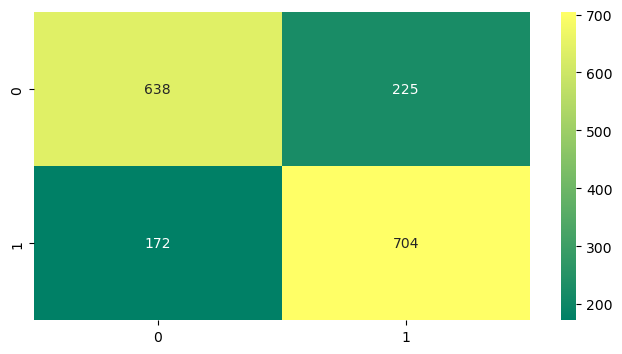

In [ ]:
model_prediction(LogisticRegression())

# KneighborsClassifier Model 

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\neighbors\_classification.py:228: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


Accuracy_Score of KNeighborsClassifier() model on Training Data is: 83.03134886396319
Accuracy_Score of KNeighborsClassifier() model on Testing Data is: 75.50316273720529

------------------------------------------------------------------------
Precision Score of KNeighborsClassifier() model is: 0.7704326923076923
Recall Score of KNeighborsClassifier() model is: 0.7317351598173516
F1 Score of KNeighborsClassifier() model is: 0.7505854800936768

------------------------------------------------------------------------
Confusion Matrix of KNeighborsClassifier() model is:


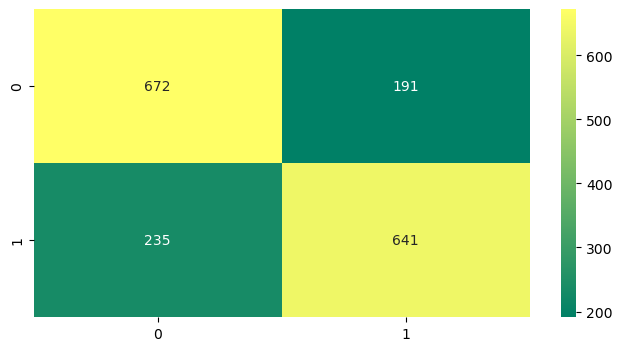

In [ ]:
model_prediction(KNeighborsClassifier())

# Support vector classifier

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1184: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Accuracy_Score of SVC() model on Training Data is: 81.8234109864826
Accuracy_Score of SVC() model on Testing Data is: 79.700977573318

------------------------------------------------------------------------
Precision Score of SVC() model is: 0.7995418098510882
Recall Score of SVC() model is: 0.7968036529680366
F1 Score of SVC() model is: 0.7981703830760436

------------------------------------------------------------------------
Confusion Matrix of SVC() model is:


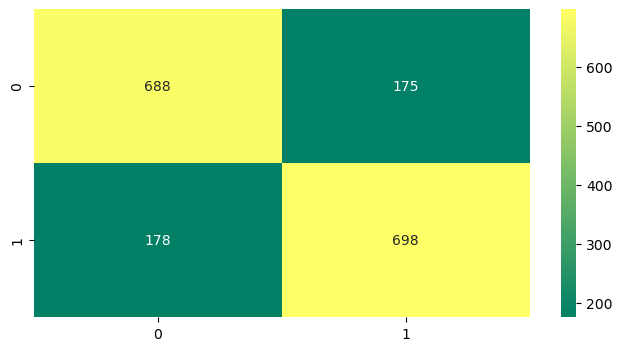

In [ ]:
model_prediction(SVC())